In [6]:
# path_to_traj = "/home/shibaev/diff/mdlm/multirun/2025-09-10/09-13-00/0/sampling_trajectories/traj_2.jsonl"
# path_to_traj = "/home/shibaev/diff/mdlm/multirun/2025-09-10/07-57-56/0/sampling_trajectories/traj_0.jsonl"
# path_to_traj = "/home/shibaev/diff/mdlm/outputs/openwebtext-train/2025.09.10/124405/sampling_trajectories/traj_0.jsonl"
# path_to_traj = "/home/shibaev/diff/mdlm/multirun/2025-09-11/07-32-03/0_steps=256_temp=1.0_p=0.9_ddpm_cache_remdm=None_eta=0.015/sampling_trajectories/traj_0.jsonl"
# path_to_traj = "/home/shibaev/diff/mdlm/multirun/2025-09-11/08-11-22/0_steps=256_temp=1.0_p=0.9_ddpm_cache_remdm=cap_eta=0.008/sampling_trajectories/traj_0.jsonl"
# path_to_traj = "/home/shibaev/diff/mdlm/multirun/2025-09-11/08-11-22/0_steps=256_temp=1.0_p=0.9_ddpm_cache_remdm=cap_eta=0.008/sampling_trajectories/traj_1.jsonl"

# path_to_traj = "/home/shibaev/diff/mdlm/multirun_remasker_head_only_seqlen512/2025-09-11/16-13-04/4_steps=256_p=0.9_t=1.0/sampling_trajectories/traj_0.jsonl"

p = "/home/shibaev/diff/mdlm/multirun_remasker_head_only_seqlen512/2025-09-11/16-13-04/5_steps=256_p=1.0_t=1.0/sampling_trajectories/traj_0.jsonl"
# p = "/home/shibaev/diff/mdlm/multirun_remasker_head_only_seqlen512/2025-09-11/16-13-04/1_steps=256_p=1.0_t=1e-09/sampling_trajectories/traj_1.jsonl"
p = "/home/shibaev/diff/mdlm/multirun_remasker_seqlen512/2025-09-12/07-47-37/0_steps=256_p=0.9_t=1.5/sampling_trajectories/traj_2.jsonl"
p = "/home/shibaev/diff/mdlm/multirun_remasker_seqlen512/2025-09-11/16-01-51/2_steps=256_p=0.9_t=0.5/sampling_trajectories/traj_0.jsonl"
p = "/home/shibaev/diff/mdlm/multirun_remasker_seqlen512/2025-09-12/07-47-37/2_steps=256_p=0.9_t=2.0/sampling_trajectories/traj_1.jsonl"
p = "/home/shibaev/diff/mdlm/multirun_remdm_0.008_seqlen512/2025-09-11/14-58-58/2_steps=256_p=0.9_remdm=loop/sampling_trajectories/traj_1.jsonl"


p = "/home/shibaev/diff/mdlm/multirun_star_shape_seqlen128/2025-09-20/13-21-55/0_steps=128_p=0.9_t=1e+100_t_on=1.0_t_off=0.0_noise=loglinear/sampling_trajectories/907796/traj_0.jsonl"

p = "/home/shibaev/diff/mdlm/multirun_star_shape_seqlen128/2025-09-21/08-42-12/0_steps=32_p=0.9_t=0_t_on=0.2_t_off=0.0_noise=loglinear/sampling_trajectories/72996/traj_32.jsonl"
p = "/home/shibaev/diff/mdlm/multirun_remasker_seqlen512/2025-09-21/18-44-08/0_steps=128_p=0.9_t=4_t_on=0.55_t_off=0.05_noise=loop/sampling_trajectories/514003/traj_0.jsonl"
p = "/home/shibaev/diff/mdlm/multirun_star_shape_seqlen128/2025-09-21/17-44-23/2_steps=128_p=0.9_t=4_t_on=0.2_t_off=0.0_noise=loglinear/sampling_trajectories/228747/traj_0.jsonl"
p = "/home/shibaev/diff/mdlm/multirun_star_shape_seqlen128/2025-09-22/08-46-27/1_steps=128_p=0.9_t=1e+100_t_on=0.3_t_off=0.0_noise=loglinear/sampling_trajectories/497623/traj_2.jsonl"

p = "/home/shibaev/diff/mdlm/multirun_star_shape_seqlen128/2025-09-22/08-46-27/0_steps=128_p=0.9_t=1.0_t_on=0.3_t_off=0.0_noise=loglinear/sampling_trajectories/282061/traj_2.jsonl"

p = "/home/shibaev/mdlm-fork/multirun_remasker_conf_seqlen512/2025-10-10/14-33-46/0_steps=128_p=0.9_t=0_t_on=0.55_t_off=0.05_noise=loop/sampling_trajectories/366922/traj_0.jsonl"
p = "/home/shibaev/mdlm-fork/multirun_remasker_conf_seqlen512/2025-10-10/14-51-33/0_steps=128_p=0.9_t=0_t_on=0.55_t_off=0.05_noise=loop/sampling_trajectories/289753/traj_3.jsonl"
p = "/home/shibaev/mdlm-fork/multirun_remasker_conf_seqlen512/2025-10-12/15-53-13/0_steps=128_p=0.9_t=0_t_on=0.55_t_off=0.05_noise=loop_fp64=False/sampling_trajectories/41520/traj_0.jsonl"
p = "/home/shibaev/mdlm-fork/multirun_remasker_seqlen512/2025-10-30/16-05-30/0_steps=32_p=0.9_t=1.0_t_on=0.55_t_off=0.05_noise=loop_fp=True_dt=0.125/sampling_trajectories/275210/traj_2.jsonl"

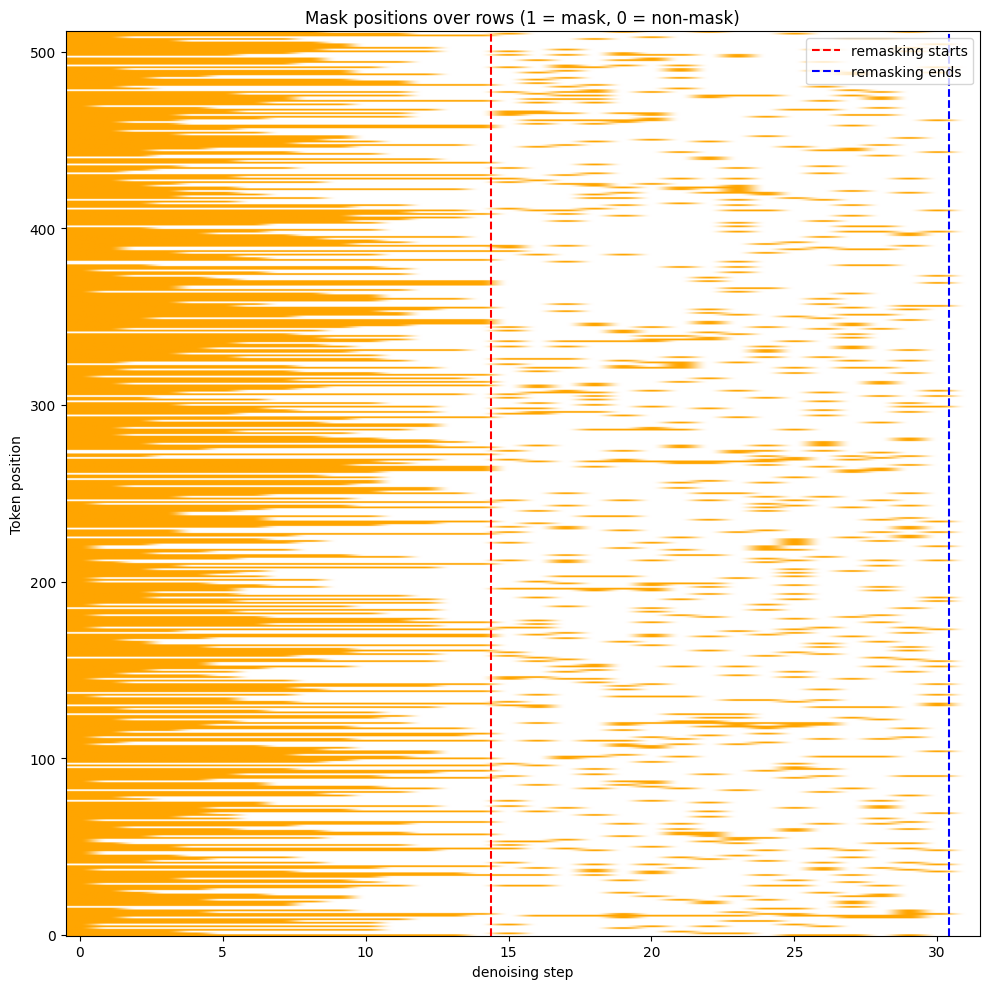

In [7]:
# mask_viz.py
import json, re, argparse, numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

def load_mask_matrix(path, mask_id=50257):
    lines = Path(path).read_text(encoding="utf-8").splitlines()
    parsed = []
    max_len = 0

    for li, line in enumerate(lines):
        if not line.strip():
            continue
        obj = json.loads(line)
        tokens = obj.get("x_tokens")

        # Fallback: if x_tokens missing, infer count from "x" string by counting "[MASK]"
        if tokens is None:
            x = obj.get("x", "")
            count = len(re.findall(r"\[MASK\]", x))
            tokens = [mask_id] * count  # we only care about mask positions here

        parsed.append(tokens)
        max_len = max(max_len, len(tokens))

    n_cols = len(parsed)
    # matrix shape: [token_position, row_index]
    mat = np.full((max_len, n_cols), np.nan, dtype=float)
    for col, toks in enumerate(parsed):
        for row, tok in enumerate(toks):
            mat[row, col] = 1.0 if tok == mask_id else 0.0

    return mat

def plot_mask_matrix(mat):
    plt.figure(figsize=(max(10, mat.shape[1] * 0.01), 10))
    # Use a custom colormap: masked positions in red, non-masked in white, NaN as gray
    from matplotlib.colors import ListedColormap
    cmap = ListedColormap(["white", "orange"])
    im = plt.imshow(mat, origin="lower", aspect="auto", cmap=cmap, vmin=0, vmax=1)
    plt.xlabel("denoising step")
    plt.ylabel("Token position")
    plt.title("Mask positions over rows (1 = mask, 0 = non-mask)")

    # Add two vertical lines for 0.55 * row and 0.05 * row
    n_cols = mat.shape[1]
    x1 = (1 - 0.55) * n_cols
    x2 = (1 - 0.05) * n_cols
    plt.axvline(x=x1, color='red', linestyle='--', label='remasking starts')
    plt.axvline(x=x2, color='blue', linestyle='--', label='remasking ends')
    plt.legend(loc='upper right')

    plt.tight_layout()
    plt.show()

mat = load_mask_matrix(p, mask_id=50257)
plot_mask_matrix(mat)

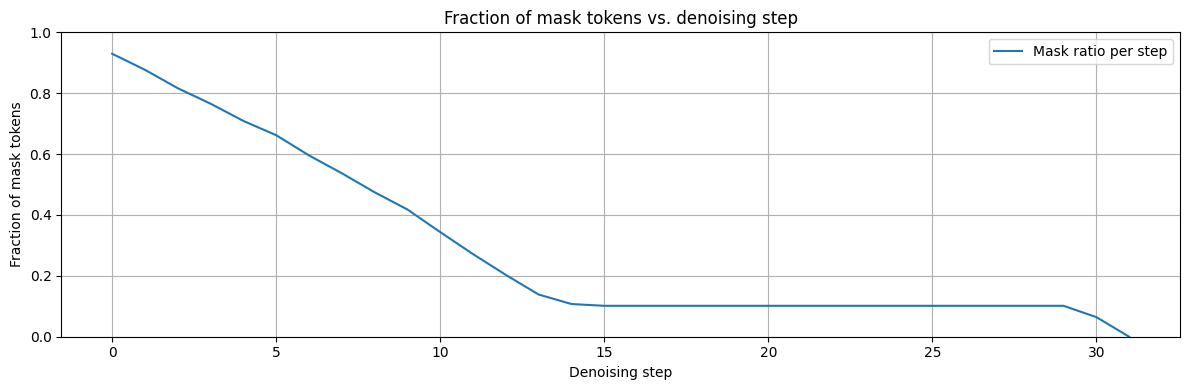

In [9]:
# Compute the ratio of mask tokens at each step (column)
mask_ratios = np.nanmean(mat, axis=0)  # mean over token positions, for each step

plt.figure(figsize=(12, 4))
plt.plot(mask_ratios, label="Mask ratio per step")
plt.xlabel("Denoising step")
plt.ylabel("Fraction of mask tokens")
plt.title("Fraction of mask tokens vs. denoising step")
plt.ylim(0, 1)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
